In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from dotenv import load_dotenv
load_dotenv()

username = os.getenv("KAGGLE_USERNAME")
key = os.getenv("KAGGLE_KEY")

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_KEY"] = key

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "nalisha/netflix-movies-and-tv-shows-data-analysis",
    path="./data",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis


In [ ]:
# Functions
def split_genres(value):
    return [g.strip() for g in str(value).split(",") if g.strip()]

In [96]:
df = pd.read_csv(
    "data/mymoviedb (1).csv",
    engine="python",
    encoding="utf-8",
    sep=",",
    quotechar='"',
    on_bad_lines="warn"
)

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [97]:
#  Show df schema
print(f"Dataset Shape: {df.shape}")
print("\n-Dataset Info-\n")
display(df.info())

# Flag missing values
print("\n-Missing Values-")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# Count unique values in each column 
print("\n-Unique Values-")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Dataset Shape: (9837, 9)

-Dataset Info-

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


None


-Missing Values-


Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64


-Unique Values-
Release_Date: 5903 unique values
Title: 9514 unique values
Overview: 9823 unique values
Popularity: 8160 unique values
Vote_Count: 3267 unique values
Vote_Average: 75 unique values
Original_Language: 44 unique values
Genre: 2337 unique values
Poster_Url: 9826 unique values


In [98]:
# Show rows that fail numeric conversion
bad = df[pd.to_numeric(df["Vote_Average"], errors="coerce").isna() & df["Vote_Average"].notna()]
print("Offending rows:", len(bad))
print(bad[["Release_Date","Title","Vote_Average","Genre"]])

# Drop the offending rows
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors="coerce")
df_clean = df[df["Vote_Average"].notna()].reset_index(drop=True)
print("After drop shape:", df_clean.shape)

Offending rows: 1
         Release_Date   Title Vote_Average Genre
1115   - Magic Tricks  61.328    Animation   NaN
After drop shape: (9826, 9)


In [99]:
# Add helper columns and clean
df["Genres"] = df["Genre"].map(split_genres)
df["Primary_Genre"] = df["Genres"].map(lambda gs: gs[0] if gs else "Unknown")

# Convert columns into numeric values
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['Vote_Average', 'Popularity'])


In [100]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url', 'Genres',
       'Primary_Genre'],
      dtype='str')

In [76]:
top10 = df.sort_values(by='Popularity', ascending=False).head(10)

top10[['Title', 'Popularity']]

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [38]:
comedy_movies = df[df['Genre'].str.contains('Comedy', na=False)]

comedy_movies[['Title', 'Genre']]

,Title,Genre
3,Encanto,"Animation, Comedy, Family, Fantasy"
14,The Ice Age Adventures of Buck Wild,"Animation, Comedy, Adventure, Family"
15,Hotel Transylvania: Transformania,"Animation, Family, Fantasy, Comedy, Adventure"
18,Looop Lapeta,"Action, Comedy, Crime"
19,Red Notice,"Action, Comedy, Crime, Thriller"
...,...,...
9814,Autumn Dreams,"Comedy, TV Movie, Romance"
9816,The Fortune Cookie,"Romance, Comedy"
9818,Viva l'Italia,Comedy
9822,Life or Something Like It,"Comedy, Drama, Romance"


In [75]:
top_rated_genre = df.sort_values(by='Vote_Average', ascending=False).head(10)

top_rated_genre[['Title', 'Primary_Genre', 'Vote_Average']]

,Title,Primary_Genre,Vote_Average
9401,Kung Fu Master Huo Yuanjia,Action,10.0
7349,Franco Escamilla: Por La Anécdota,Comedy,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,Action,9.1
2335,Impossible Things,Family,9.1
7411,My Sex Doll,Comedy,9.0
6738,Mission «Sky»,Drama,9.0
7024,Sex School: Dorms of Desire,Comedy,9.0
2401,The Three Deaths of Marisela Escobedo,Documentary,9.0
7049,Bring the Soul: The Movie,Music,8.9
5079,"Ni tuyo, Ni mía",Drama,8.9


In [ ]:
# Visualize using plotly express
import plotly.express as px

fig = px.bar(top10, x='Popularity', y='Title', orientation='h')
fig.update_yaxes(tickfont=dict(size=10))
fig.update_layout(title="Top 10 Most Popular Movies on Netflix")
fig.show()

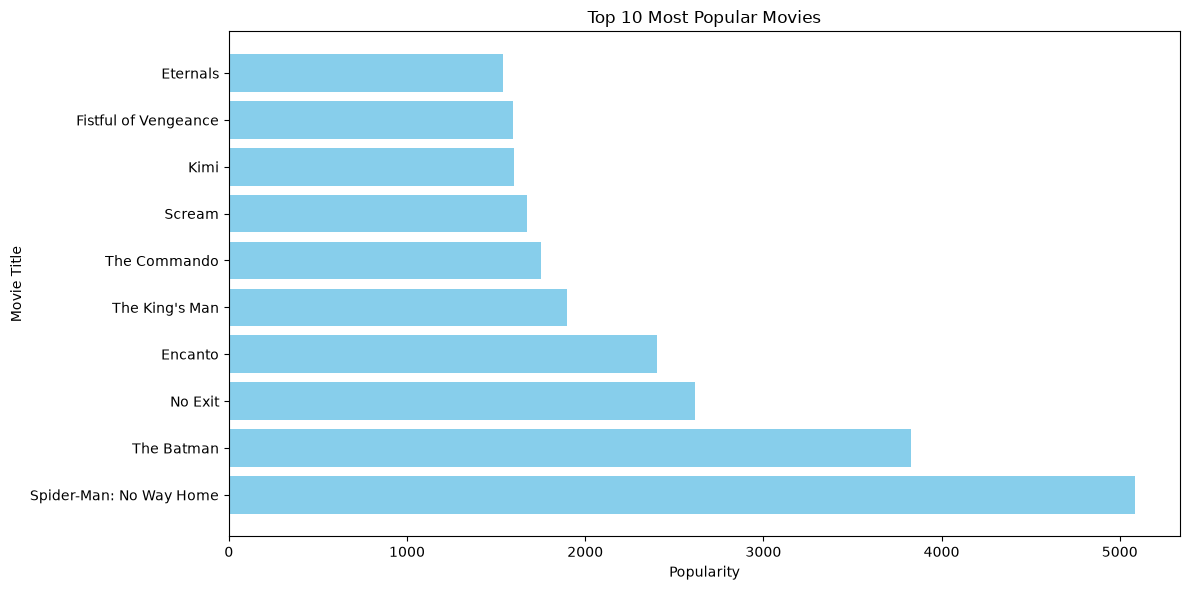

In [87]:
# Visualize using matplotlib
plt.figure(figsize=(12,6))

plt.barh(top10['Title'], top10['Popularity'], color='skyblue')
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Popular Movies")

plt.tight_layout()
plt.show()

In [88]:
# Visualize using plotly graph objects
import plotly.graph_objects as go

# 1. Define your categorical and numerical data
categories = top10['Title'].tolist()
values = top10['Popularity'].tolist()

# 2. Initialize the figure
fig = go.Figure()

# 3. Add the horizontal bar trace
fig.add_trace(go.Bar(
    x=values,
    y=categories,
    orientation='h'
))

fig.update_layout(title="Top 10 Most Popular Movies on Netflix")

# 4. Display the chart
fig.show()

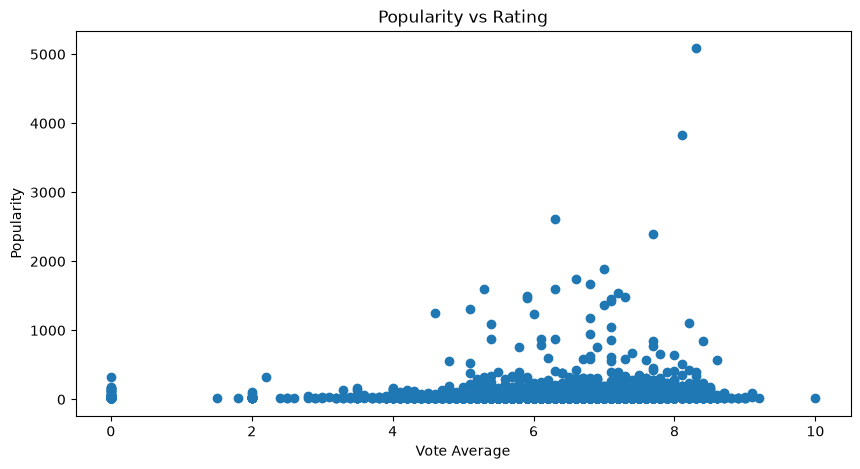

In [92]:
# Scatter Plot
plt.figure(figsize=(10,5))

plt.scatter(df['Vote_Average'], df['Popularity'])

plt.xlabel("Vote Average")
plt.ylabel("Popularity")
plt.title("Popularity vs Rating")

plt.show()

In [101]:
fig = px.scatter(df, x="Vote_Average", y="Popularity",
	         size="Popularity", color="Vote_Average",
                 hover_name="Title", log_x=True, size_max=60)
fig.show()

In [112]:
# Visualize using plotly graph objects
fig = go.Figure(data=[go.Scatter(
    x=df['Vote_Average'], y=df['Popularity'],
    mode='markers',
    marker_size=df['Popularity'] / 50)
])

fig.show()